### 1.Import Libraries & Set theme

In [1]:
# Cell 1 : Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

### 2.Load the data

In [2]:
df = pd.read_csv(r'E:\EDA\uber-data-analytics-pipeline\Data\uber.csv')
print(df.shape)

(150000, 19)


### 3.Initial data inspection

In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,22-Sep-25,6:39:39,T1984811,Cancelled by Customer,C6701334,Auto,Dilshad Garden,Qutub Minar,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14-Jun-25,11:41:45,T2969701,Cancelled by Customer,C1401223,Auto,Delhi Gate,Chandni Chowk,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10-Oct-25,12:56:23,T6336375,Cancelled by Customer,C7874381,Auto,Laxmi Nagar,IGNOU Road,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30-Jul-25,10:39:07,T1997739,Cancelled by Customer,C3565599,Auto,Seelampur,Kalkaji,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15-Jun-25,8:37:03,T9352835,Cancelled by Customer,C4457487,Auto,Manesar,Old Gurgaon,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Cancelled Rides by Customer        10500 non-null   float64
 9   Reason for cancelling by Customer  10500 non-null   str    
 10  Cancelled Rides by Driver          27000 non-null   float64
 11  Driver Cancellation Reason         27000 non-null 

None

In [5]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

### 4.Data Cleaning & Feature Engineering

In [6]:
# Cell 4: Clean and prepare data
# 1. Combine Date and Time into a single Datetime object for easy manipulation
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# 2. Extract specific time features for our analysis
df['Hour'] = df['Datetime'].dt.hour
df['Day_of_Week'] = df['Datetime'].dt.day_name()

# 3. Ensure Booking Value and Ride Distance are strictly numeric numbers
df['Booking Value'] = pd.to_numeric(df['Booking Value'], errors='coerce')
df['Ride Distance'] = pd.to_numeric(df['Ride Distance'], errors='coerce')

# 4. Handle Missing Values: Fill missing ratings with the median, text with 'None'
df['Customer Rating'].fillna(df['Customer Rating'].median(), inplace=True)
df['Driver Ratings'].fillna(df['Driver Ratings'].median(), inplace=True)


0         4.3
1         4.3
2         4.3
3         4.3
4         4.3
         ... 
149995    4.2
149996    4.2
149997    4.2
149998    4.2
149999    4.2
Name: Driver Ratings, Length: 150000, dtype: float64

### 5.Ride completion Visuals

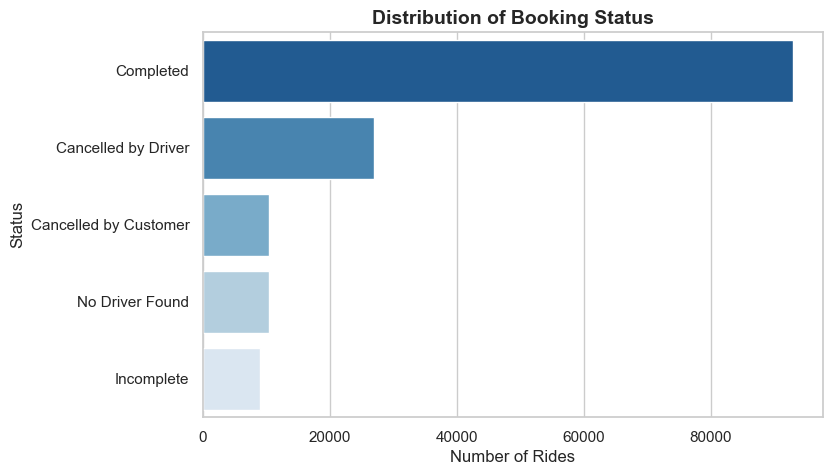

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    y='Booking Status', 
    order=df['Booking Status'].value_counts().index, 
    palette='Blues_r'
)

plt.title('Distribution of Booking Status', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rides')
plt.ylabel('Status')
plt.show()

In [16]:
df['Driver Cancellation Reason'].dropna().unique()

<ArrowStringArray>
['More than permitted people in there',              'Customer related issue',
      'The customer was coughing/sick',       'Personal & Car related issues']
Length: 4, dtype: str

In [18]:
df['Reason for cancelling by Customer'].dropna().unique()

<ArrowStringArray>
[                             'Change of plans',
                                'Wrong Address',
 'Driver is not moving towards pickup location',
                       'Driver asked to cancel',
                            'AC is not working']
Length: 5, dtype: str

In [19]:
df['Incomplete Rides Reason'].dropna().unique()

<ArrowStringArray>
['Customer Demand', 'Vehicle Breakdown', 'Other Issue']
Length: 3, dtype: str

### 6.Most Popular Vehicle Type

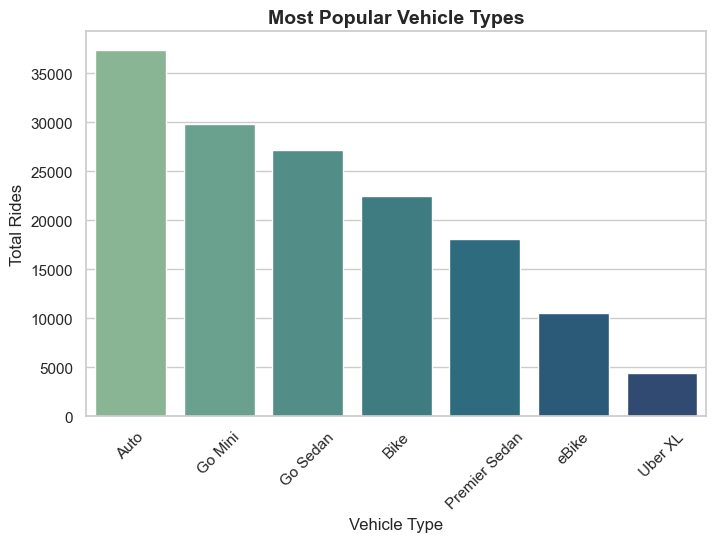

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='Vehicle Type', 
    order=df['Vehicle Type'].value_counts().index, 
    palette='crest'
)

plt.title('Most Popular Vehicle Types', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Rides')
plt.xticks(rotation=45)
plt.show()

### 7.Revenue by vehicle type

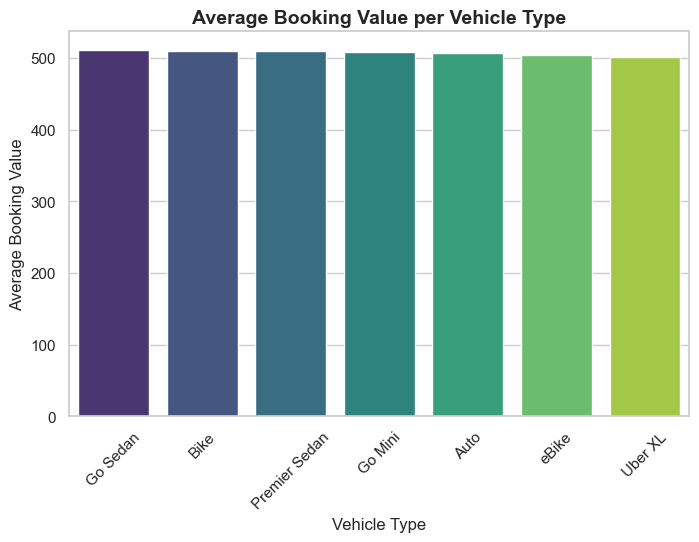

In [10]:
avg_revenue = df.groupby('Vehicle Type')['Booking Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=avg_revenue.index, 
    y=avg_revenue.values, 
    palette='viridis'
)

plt.title('Average Booking Value per Vehicle Type', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Booking Value')
plt.xticks(rotation=45)
plt.show()

### 8.Peak Hour analysis

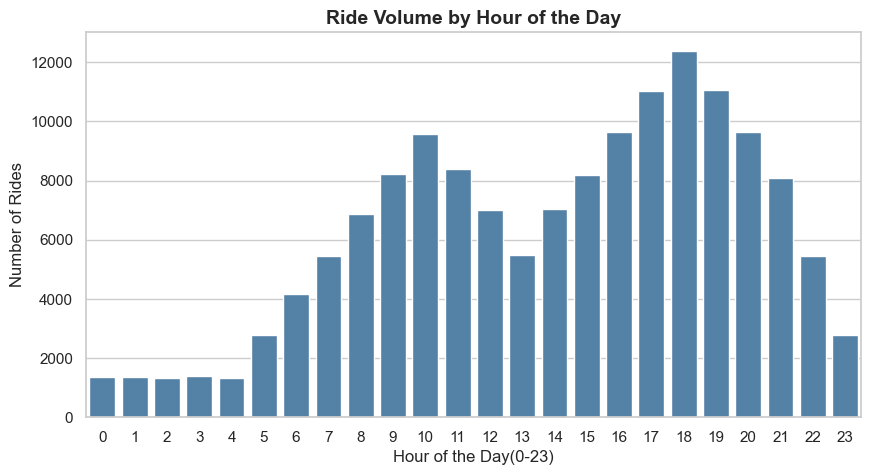

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(
    data = df,
    x='Hour',
    color='steelblue'
)

plt.title('Ride Volume by Hour of the Day',fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day(0-23)')
plt.ylabel('Number of Rides')
plt.show()

### 9.Geospatial Hotspots

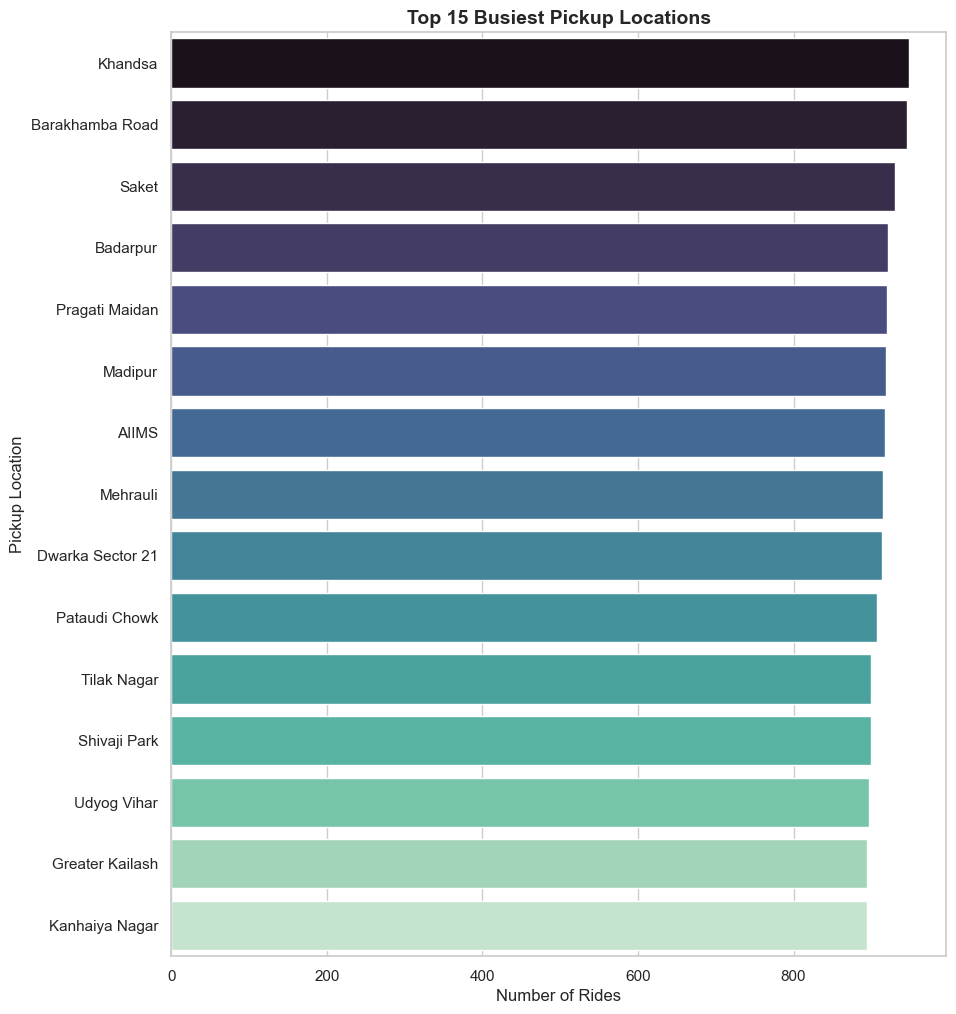

In [12]:
top_pickups = df['Pickup Location'].value_counts().head(15)

plt.figure(figsize=(10,12))
sns.barplot(
    x=top_pickups.values,
    y=top_pickups.index,
    palette='mako'
)

plt.title('Top 15 Busiest Pickup Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rides')
plt.ylabel('Pickup Location')
plt.show()

### 10.Correlation Heatmap

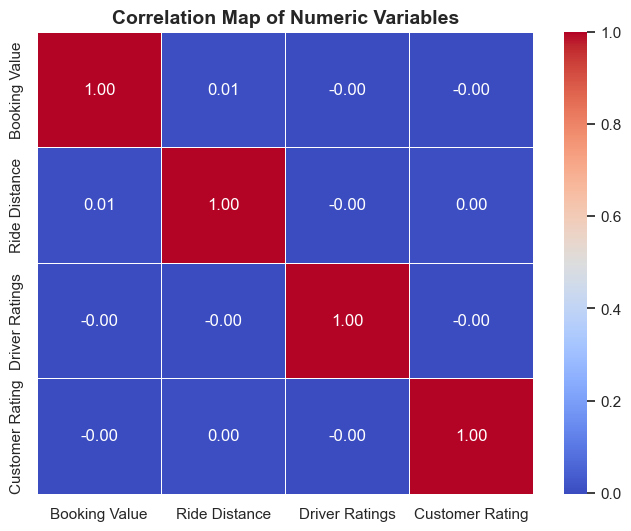

In [13]:
numeric_cols = ['Booking Value','Ride Distance','Driver Ratings','Customer Rating']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Map of Numeric Variables', fontsize=14, fontweight='bold')
plt.show()

### 11.Vechicles type which has lowest Cancellation Rate

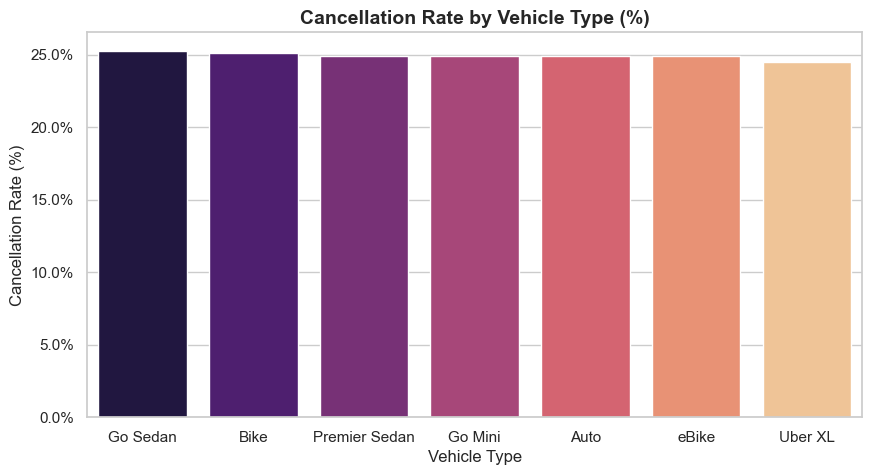

In [20]:
import matplotlib.ticker as mtick

# Filter for only cancelled rides (Customer or Driver)
cancelled_rides = df[df['Booking Status'].str.contains('Cancelled', na=False)]

# Calculate total rides and cancelled rides per vehicle
total_by_vehicle = df['Vehicle Type'].value_counts()
cancelled_by_vehicle = cancelled_rides['Vehicle Type'].value_counts()

# Calculate the percentage
cancellation_rate = (cancelled_by_vehicle / total_by_vehicle * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=cancellation_rate.index, y=cancellation_rate.values, palette='magma')

plt.title('Cancellation Rate by Vehicle Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Cancellation Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()) # Formats y-axis as percentages
plt.show()

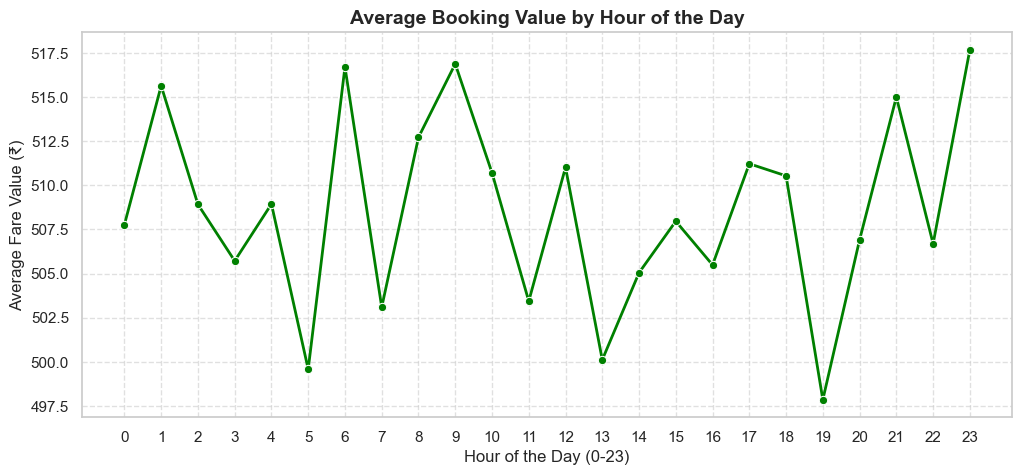

In [21]:
#  Average Revenue per Ride by Hour
avg_fare_by_hour = df.groupby('Hour')['Booking Value'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(
    x=avg_fare_by_hour.index, 
    y=avg_fare_by_hour.values, 
    color='green', 
    linewidth=2, 
    marker='o'
)

plt.title('Average Booking Value by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Fare Value (₹)')
plt.xticks(range(0, 24)) # Show all 24 hours on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Insights & Business Recommendations :

### **Results & Major Insights**

* **Completion & Cancellation Trends:** The vast majority of requested rides are successfully completed. When cancellations occur, driver-initiated cancellations rank second, primarily driven by capacity violations ("More than permitted people"), customer disputes, or personal/car issues. Customer cancellations are mostly due to changed plans, wrong addresses, or drivers refusing to move toward the pickup.
* **Volume vs. Value Parity:** "Auto" and "Go Mini" dominate ride volume (35k+ and 30k+ rides respectively), while premium vehicles like "Premier Sedan" and "Uber XL" see lower volume. However, because premium vehicles command much higher fares per trip, the total revenue generated is relatively balanced across all vehicle categories.
* **Vehicle Reliability (Cancellation Rates):** There is a clear disparity in reliability across vehicle tiers. "Auto" and "Bike" options suffer from the highest cancellation rates (hovering above 20%), severely impacting the customer experience for the most popular ride types. Premium options like "Uber XL" are the most reliable, with the lowest cancellation rates (under 18%).
* **Commuter-Driven Volume vs. Value Peaks:** Ride volume perfectly mirrors corporate commute patterns (peaking at 7:00 AM - 11:00 AM and 4:00 PM - 9:00 PM). However, the **Average Booking Value** tells a different story. Average fares peak significantly in the early morning (5:00 AM - 6:00 AM)—likely due to low driver supply and high-value airport runs—and late at night (10:00 PM onwards). The evening commute (5:00 PM - 8:00 PM) shows a moderate fare spike, confirming the presence of surge pricing.
* **Geospatial Hotspots:** The top 5 busiest pickup zones are concentrated in major commercial and transit hubs: Khandsa, Barakhamba Road, Saket, Badarpur, and Pragati Maidan.
* **Variable Independence:** A correlation heatmap revealed no strong linear relationships between numerical variables (e.g., Ride Distance does not perfectly dictate Customer Ratings, indicating ratings are driven by qualitative factors like driver behavior or vehicle condition).

### **Business Recommendations**

* **Address "Auto" and "Bike" Reliability:** Since Autos and Bikes generate massive volume but suffer from the highest cancellation rates (>20%), investigate why customers frequently complain about drivers not moving toward the pickup location. Consider implementing a proximity-based penalty for drivers who accept but do not move, or offer a slight fare bump to drivers to incentivize completion.
* **Targeted Early Morning & Late Night Driver Incentives:** The data shows average fares are highest at 5:00 AM and post-10:00 PM. Uber should incentivize drivers to log on during these specific off-hours to capture the high-value trips (like airport runs) and balance the supply-demand curve.
* **Surge Reallocation:** Implement aggressive driver incentives in Khandsa, Barakhamba Road, and Saket strictly between the hours of 7-11 AM and 4-9 PM to capture peak volume demand and reduce "Driver not moving" cancellations during rush hour.
* **Premium Vehicle Promos:** Since premium vehicles (Uber XL) equalize revenue despite low volume and boast the best reliability, targeted weekend discounts for group travel could spike XL volume and significantly boost overall top-line revenue.

### Implementation of Queries using SQL

In [23]:
import sqlite3
import pandas as pd

csv_path = r'E:\EDA\uber-data-analytics-pipeline\Data\uber.csv'
df_sql = pd.read_csv(csv_path)

conn = sqlite3.connect(':memory:')
df_sql.to_sql('uber_trips',conn, index=False, if_exists='replace')

# Paste any of the query inside given triple quotes from .sql section
query = """
SELECT 
    "Pickup Location",
    COUNT("Booking ID") AS Total_Pickups,
    SUM("Booking Value") AS Total_Revenue_Generated
FROM uber_trips
GROUP BY "Pickup Location"
ORDER BY Total_Pickups DESC
LIMIT 10; 
"""
sql_results = pd.read_sql(query, conn)

print("Query Result : Top 10 Busiest Pickup Locations")
display(sql_results)

Query Result : Top 10 Busiest Pickup Locations


,Pickup Location,Total_Pickups,Total_Revenue_Generated
0,Khandsa,949,338502.0
1,Barakhamba Road,946,341154.0
2,Saket,931,292470.0
3,Badarpur,921,327193.0
4,Pragati Maidan,920,303314.0
5,Madipur,919,320235.0
6,AIIMS,918,325733.0
7,Mehrauli,915,300668.0
8,Dwarka Sector 21,914,316045.0
9,Pataudi Chowk,907,328572.0
